# Cross-Country Comparison & Climate Vulnerability Ranking

### Import libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import f_oneway, kruskal

### Load datas

In [2]:
data_dir = "data"
clean_files = [f for f in os.listdir(data_dir) if f.endswith("_clean.csv")]

dfs = []
for f in clean_files:
    country = f.replace("_clean.csv", "")
    path = os.path.join(data_dir, f)
    df_country = pd.read_csv(path)
    dfs.append(df_country)

df_all = pd.concat(dfs, ignore_index=True)

# Preview
print(f"Loaded {len(clean_files)} files")
print(df_all.shape)
df_all.head()

Loaded 5 files
(20539, 14)


,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


## Temperature Trend Comparison

In [3]:
df_all.head()

,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


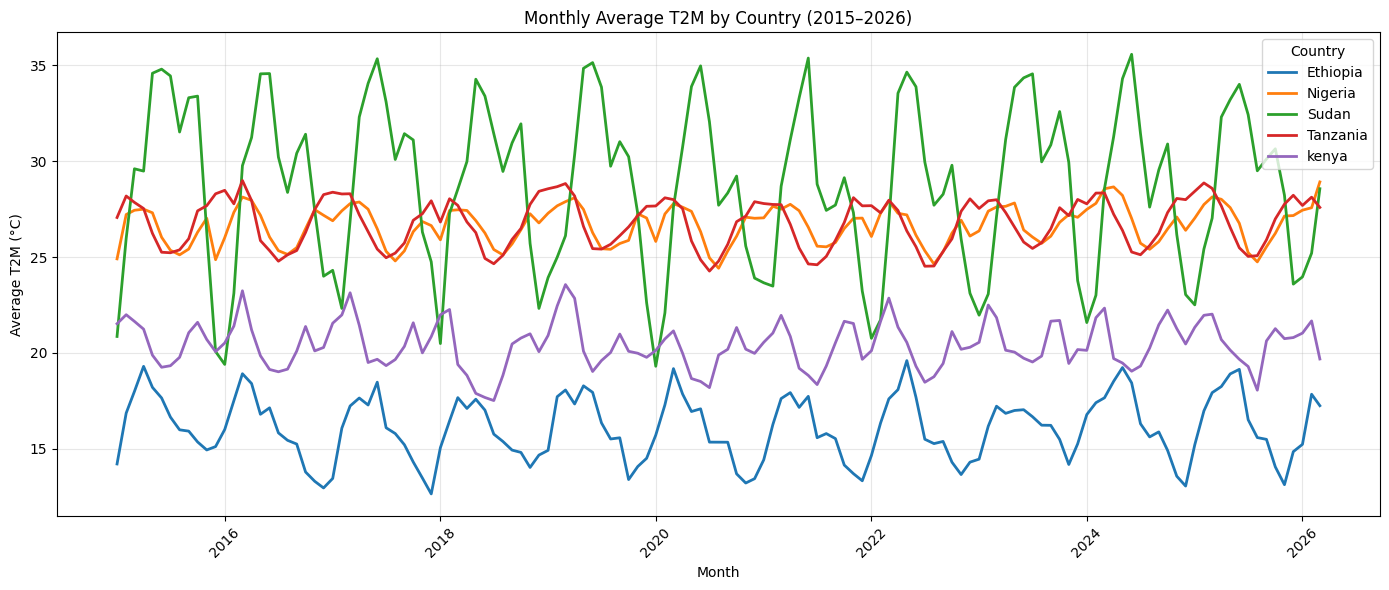

In [4]:
# Monthly average T2M by country (2015–2026) from df_all
monthly_t2m = df_all.copy()
monthly_t2m["Date"] = pd.to_datetime(monthly_t2m["Date"], errors="coerce")
monthly_t2m["YearMonth"] = monthly_t2m["Date"].dt.to_period("M").dt.to_timestamp()

monthly_avg = (
    monthly_t2m
    .groupby(["Country", "YearMonth"], as_index=False)["T2M"]
    .mean()
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_avg, x="YearMonth", y="T2M", hue="Country", linewidth=2)
plt.title("Monthly Average T2M by Country (2015–2026)")
plt.xlabel("Month")
plt.ylabel("Average T2M (°C)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# Summary table: mean, median, and standard deviation of T2M by country
t2m_summary = (
    df_all.groupby("Country")["T2M"]
    .agg(mean="mean", median="median", std="std")
    .reset_index()
    .sort_values("mean", ascending=False)
)

t2m_summary

,Country,mean,median,std
2,Sudan,28.758320,29.16,4.681668
3,Tanzania,26.802422,26.99,1.325388
1,Nigeria,26.656928,26.82,1.123335
4,kenya,20.427600,20.36,1.440824
0,Ethiopia,16.068500,16.04,1.898050


## Precipitation Variability Comparison

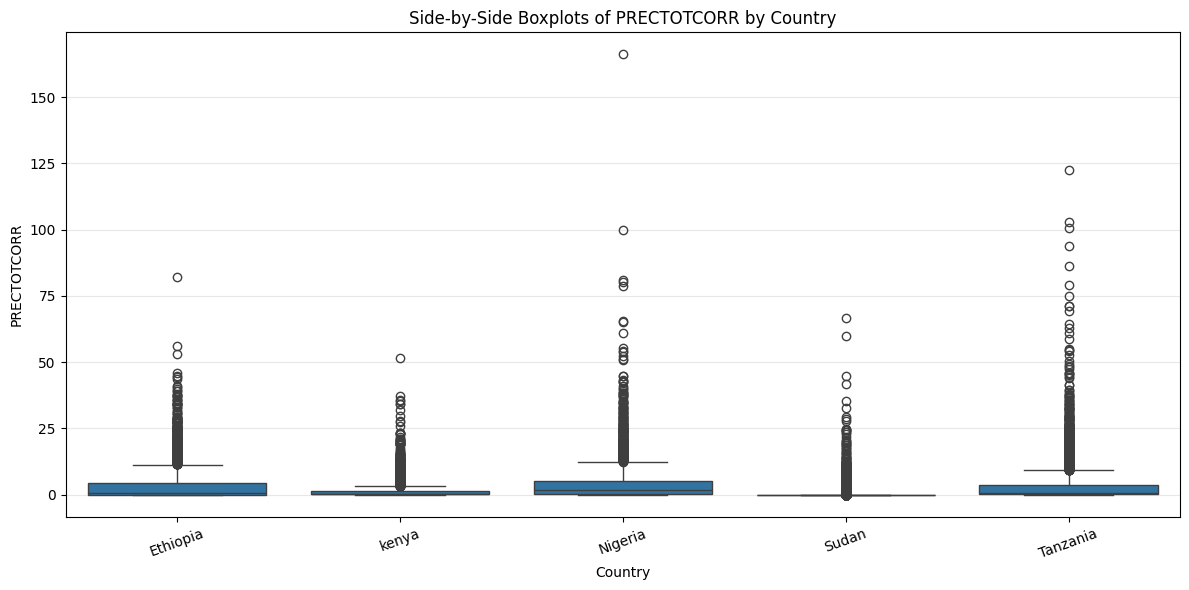

In [6]:
plt.figure(figsize=(12, 6))

country_order = sorted(df_all["Country"].dropna().unique(), key=lambda x: x.lower())
sns.boxplot(
    data=df_all,
    x="Country",
    y="PRECTOTCORR",
    order=country_order
)

plt.title("Side-by-Side Boxplots of PRECTOTCORR by Country")
plt.xlabel("Country")
plt.ylabel("PRECTOTCORR")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Summary table: mean, median, and standard deviation of PRECTOTCORR  by country
prect_summary = (
    df_all.groupby("Country")["PRECTOTCORR"]
    .agg(mean="mean", median="median", std="std")
    .reset_index()
    .sort_values("mean", ascending=False)
)

prect_summary

,Country,mean,median,std
1,Nigeria,4.213914,1.84,7.266742
3,Tanzania,3.740256,0.64,8.003947
0,Ethiopia,3.633795,0.82,6.289061
4,kenya,1.468162,0.38,3.180228
2,Sudan,0.630884,0.00,2.942469


## Extreme Event Frequency

In [8]:
# Count extreme heat days (T2M_MAX > 35°C) per country per year
extreme_heat_counts = (
    df_all[df_all["T2M_MAX"] > 35]
    .groupby(["Country", "YEAR"])
    .size()
    .reset_index(name="ExtremeHeatDays")
    .sort_values(["Country", "YEAR"])
)

extreme_heat_counts

,Country,YEAR,ExtremeHeatDays
0,Sudan,2015,280
1,Sudan,2016,252
2,Sudan,2017,266
3,Sudan,2018,248
4,Sudan,2019,251
5,Sudan,2020,195
6,Sudan,2021,212
7,Sudan,2022,202
8,Sudan,2023,262
9,Sudan,2024,223


In [9]:
# Consecutive dry-day analysis (PRECTOTCORR < 1 mm) by country and year
dry_df = df_all.copy()
dry_df["Date"] = pd.to_datetime(dry_df["Date"], errors="coerce")
dry_df = dry_df.dropna(subset=["Date"]).sort_values(["Country", "Date"])

dry_df["YEAR"] = dry_df["Date"].dt.year
dry_df["is_dry"] = dry_df["PRECTOTCORR"] < 1

# Create streak IDs within each country-year whenever dry/wet status changes
dry_df["streak_id"] = (
    dry_df.groupby(["Country", "YEAR"])["is_dry"]
    .transform(lambda s: s.ne(s.shift()).cumsum())
)

# Length of each dry streak
dry_streaks = (
    dry_df[dry_df["is_dry"]]
    .groupby(["Country", "YEAR", "streak_id"])
    .size()
    .reset_index(name="ConsecutiveDryDays")
)

# Main result: longest consecutive dry streak per country-year
dry_streaks_per_year = (
    dry_streaks.groupby(["Country", "YEAR"], as_index=False)["ConsecutiveDryDays"]
    .max()
    .rename(columns={"ConsecutiveDryDays": "MaxConsecutiveDryDays"})
    .sort_values(["Country", "YEAR"])
)

dry_streaks_per_year

,Country,YEAR,MaxConsecutiveDryDays
0,Ethiopia,2015,25
1,Ethiopia,2016,35
2,Ethiopia,2017,43
3,Ethiopia,2018,35
4,Ethiopia,2019,46
5,Ethiopia,2020,39
6,Ethiopia,2021,28
7,Ethiopia,2022,29
8,Ethiopia,2023,55
9,Ethiopia,2024,38


In [10]:
# Normalize country labels and use a consistent color per country
country_order = sorted(
    df_all["Country"].dropna().astype(str).str.strip().str.title().unique()
)
palette = dict(zip(country_order, sns.color_palette("tab10", len(country_order))))
all_years = sorted(df_all["YEAR"].dropna().unique())

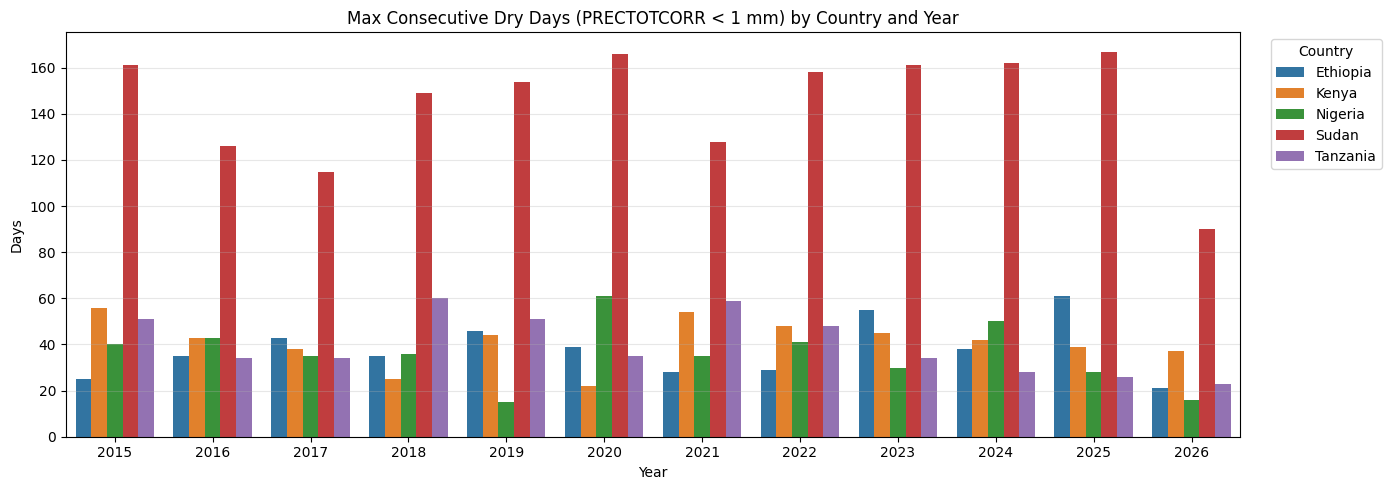

In [11]:
dry_plot = dry_streaks_per_year.copy()
dry_plot["Country"] = dry_plot["Country"].astype(str).str.strip().str.title()

dry_plot_full = (
    pd.MultiIndex.from_product([country_order, all_years], names=["Country", "YEAR"])
    .to_frame(index=False)
    .merge(dry_plot, on=["Country", "YEAR"], how="left")
    .fillna({"MaxConsecutiveDryDays": 0})
)

# Creating a dedicated, separate figure for the first metric
plt.figure(figsize=(14, 5))
sns.barplot(
    data=dry_plot_full,
    x="YEAR",
    y="MaxConsecutiveDryDays",
    hue="Country",
    order=all_years,
    hue_order=country_order,
    palette=palette,
)
plt.title("Max Consecutive Dry Days (PRECTOTCORR < 1 mm) by Country and Year")
plt.xlabel("Year")
plt.ylabel("Days")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

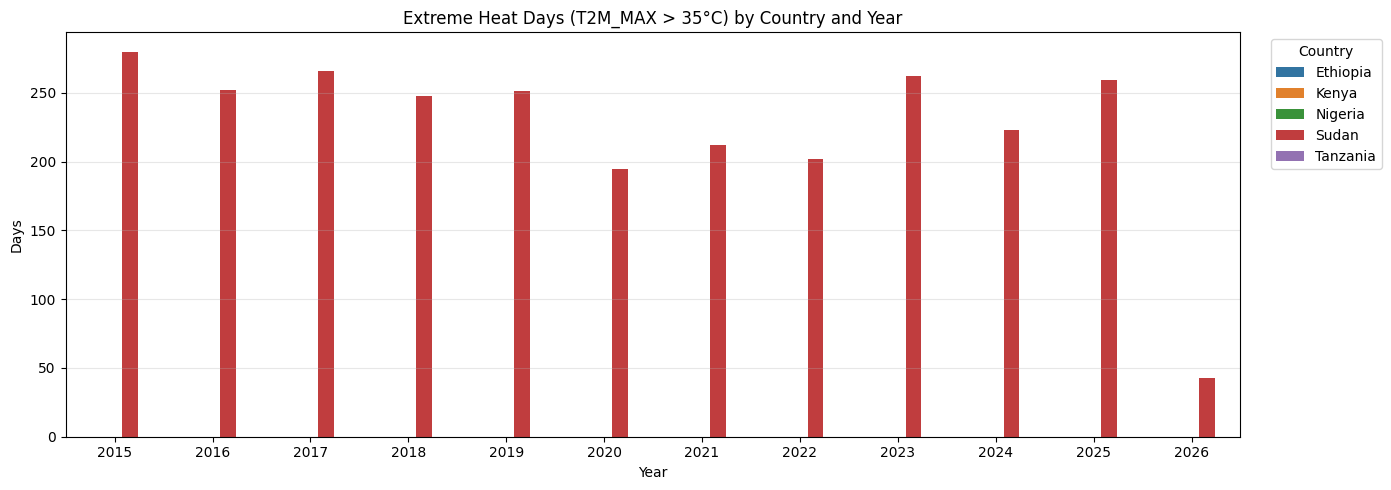

In [12]:
# ==========================================
# Metric 2: Extreme Heat Days
# ==========================================
heat_plot = extreme_heat_counts.copy()
heat_plot["Country"] = heat_plot["Country"].astype(str).str.strip().str.title()

heat_plot_full = (
    pd.MultiIndex.from_product([country_order, all_years], names=["Country", "YEAR"])
    .to_frame(index=False)
    .merge(heat_plot, on=["Country", "YEAR"], how="left")
    .fillna({"ExtremeHeatDays": 0})
)

# Creating a dedicated, separate figure for the second metric
plt.figure(figsize=(14, 5))
sns.barplot(
    data=heat_plot_full,
    x="YEAR",
    y="ExtremeHeatDays",
    hue="Country",
    order=all_years,
    hue_order=country_order,
    palette=palette,
)
plt.title("Extreme Heat Days (T2M_MAX > 35°C) by Country and Year")
plt.xlabel("Year")
plt.ylabel("Days")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Statistical Testing

Significant differences exist among country mean T2M values and Significant differences exist among country T2M distributions.

In [ ]:
df_all["Date"] = pd.to_datetime(df_all["Date"], errors="coerce")

df_test = df_all[["Country", "T2M"]].dropna()
countries = df_test["Country"].unique()
groups = [df_test[df_test["Country"] == country]["T2M"].values for country in countries]

anova_stat, anova_p = f_oneway(*groups)

print("One-Way ANOVA Results")
print("----------------------")
print(f"F-statistic : {anova_stat:.4f}")
print(f"P-value     : {anova_p:.6f}")

if anova_p < 0.05:
    print("Result: Significant differences exist among country mean T2M values.")
else:
    print("Result: No significant difference among country mean T2M values.")

# -----------------------------
# 2. Kruskal-Wallis Test
# -----------------------------
kw_stat, kw_p = kruskal(*groups)

print("\nKruskal-Wallis Results")
print("----------------------")
print(f"H-statistic : {kw_stat:.4f}")
print(f"P-value     : {kw_p:.6f}")

if kw_p < 0.05:
    print("Result: Significant differences exist among country T2M distributions.")
else:
    print("Result: No significant difference among country distributions.")

One-Way ANOVA Results
----------------------
F-statistic : 18936.8394
P-value     : 0.000000
Result: Significant differences exist among country mean T2M values.

Kruskal-Wallis Results
----------------------
H-statistic : 15392.1964
P-value     : 0.000000
Result: Significant differences exist among country T2M distributions.


## Vulnerability Ranking & Key Observations

In [14]:
# 1. Setup and Data Cleaning
df = df_all.copy()
df["Country"] = df["Country"].astype(str).str.strip().str.title()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date", "T2M", "PRECTOTCORR"]).copy()

countries = sorted(df["Country"].unique())
years = sorted(df["YEAR"].unique())

# --- METRIC 1: Warming Trend (°C per decade) ---
temp_monthly = (
    df.assign(YearMonth=df["Date"].dt.to_period("M").dt.to_timestamp())
      .groupby(["Country", "YearMonth"], as_index=False)["T2M"]
      .mean()
)

warming_rows = []
for c, g in temp_monthly.groupby("Country"):
    g = g.sort_values("YearMonth")
    # Convert dates to years since start for linear regression
    x = (g["YearMonth"] - g["YearMonth"].min()).dt.days / 365.25
    y = g["T2M"].values
    # Slope * 10 = degrees per decade
    slope_per_decade = np.polyfit(x, y, 1)[0] * 10 if len(g) > 1 else 0
    warming_rows.append({"Country": c, "WarmingRate": slope_per_decade})

warming_df = pd.DataFrame(warming_rows)

# --- METRIC 2: Precipitation Variability (Instability & Flood Risk) ---
precip_df = (
    df.groupby("Country")["PRECTOTCORR"]
      .agg(
          PrecipStd="std",   # Measures Unpredictability
          PrecipP95=lambda s: s.quantile(0.95) # Measures Flood/Extreme event intensity
      )
      .reset_index()
)

HEAT_THRESHOLD = 35

heat_counts = (
    df.assign(HeatDay=(df["T2M_MAX"] > HEAT_THRESHOLD).astype(int))
      .groupby(["Country", "YEAR"])["HeatDay"]
      .sum()
      .reset_index()
)

heat_df = (
    heat_counts.groupby("Country", as_index=False)["HeatDay"]
    .mean()
    .rename(columns={"HeatDay": "AvgAnnualHeatDays"})
)

# --- METRIC 4: Drought Stress (Consecutive Dry Days) ---
def get_max_dry_streak(series):
    is_dry = (series < 1).astype(int)
    return is_dry.groupby((is_dry != is_dry.shift()).cumsum()).sum().max()

drought_counts = (
    df.groupby(["Country", "YEAR"])["PRECTOTCORR"]
    .apply(get_max_dry_streak)
    .reset_index(name="MaxDryStreak")
)

drought_df = (
    drought_counts.groupby("Country", as_index=False)["MaxDryStreak"]
    .mean()
    .rename(columns={"MaxDryStreak": "AvgMaxDryStreak"})
)

# 2. Combine and Normalize (Composite Score)
vulnerability = (
    warming_df.merge(precip_df, on="Country")
              .merge(heat_df, on="Country")
              .merge(drought_df, on="Country")
)

# Convert raw values to percentile ranks (0 to 1 scale)
vulnerability["Score_Warming"] = vulnerability["WarmingRate"].rank(pct=True)
vulnerability["Score_Precip"]  = (0.6 * vulnerability["PrecipStd"].rank(pct=True)) + \
                                (0.4 * vulnerability["PrecipP95"].rank(pct=True))
vulnerability["Score_Heat"]    = vulnerability["AvgAnnualHeatDays"].rank(pct=True)
vulnerability["Score_Drought"] = vulnerability["AvgMaxDryStreak"].rank(pct=True)

# Final Composite Score (Equal weights)
vulnerability["VulnerabilityScore"] = (
    vulnerability[["Score_Warming", "Score_Precip", "Score_Heat", "Score_Drought"]].mean(axis=1)
)

# 3. Final Table Formatting
vulnerability_table = (
    vulnerability.sort_values("VulnerabilityScore", ascending=False)
    .assign(Rank=lambda d: range(1, len(d) + 1))
    [[
        "Rank", "Country", "VulnerabilityScore",
        "WarmingRate", "PrecipStd", "PrecipP95",
        "AvgAnnualHeatDays", "AvgMaxDryStreak"
    ]]
)

print("COP32 Climate Vulnerability Ranking")
display(vulnerability_table.round(3))

COP32 Climate Vulnerability Ranking


,Rank,Country,VulnerabilityScore,WarmingRate,PrecipStd,PrecipP95,AvgAnnualHeatDays,AvgMaxDryStreak
4,1,Tanzania,0.725,0.159,8.004,17.314,0.000,40.250
2,2,Nigeria,0.605,0.476,7.267,16.055,0.000,35.833
3,3,Sudan,0.600,-0.621,2.942,3.321,224.417,144.750
0,4,Ethiopia,0.545,0.011,6.289,16.372,0.000,37.917
1,5,Kenya,0.525,-0.007,3.180,6.530,0.000,41.083


*   **Fastest warming:** **Nigeria** is warming fastest at approximately **0.48 °C/decade**. This rapid upward trend suggests accelerating long-term heat exposure and rising adaptation pressure, significantly outpacing the other countries in the study.
*   **Most unstable precipitation:** **Tanzania** exhibits the most extreme precipitation patterns, showing the highest rainfall variability (**std = 8.00**) and the most intense deluge events (**95th percentile = 17.31**). This indicates stronger, more dangerous swings between heavy rain events and dry periods compared to its neighbors.
*   **Extreme heat + drought stress:** **Sudan** reveals a catastrophic level of climate stress, with a massive frequency of extreme heat (**224.42 days/year**) and the longest prolonged dry spells (**144.75 days**). This data highlights a severe compound risk profile where extreme thermal stress and chronic water scarcity overlap.
*   **Ethiopia vs neighbors:** Ethiopia ranks **#4** in overall vulnerability. While it shows lower extreme heat than Sudan, its precipitation instability (**std = 6.29**) and extreme rainfall intensity (**P95 = 16.37**) are significantly higher than both Kenya and Sudan, indicating a profile defined more by hydrological volatility than thermal extremes.
*   **Priority climate-finance champion (COP32):** Ethiopia should prioritize **Tanzania** for climate finance, as it holds the highest composite vulnerability score (**0.73**). The data supports this as Tanzania faces the most severe combination of rainfall instability, flood risk, and drought stress in the region, making it the most critical hotspot for immediate adaptation investment.